In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv(r'train.csv')
df.sample(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
340559,340559,Male,0,Yes,No,45,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Credit card (automatic),65.7,3274.35,No
374675,374675,Male,0,No,No,45,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.3,844.45,No


In [3]:
df[ 'PaymentMethod'].unique()

array(['Mailed check', 'Credit card (automatic)', 'Electronic check',
       'Bank transfer (automatic)'], dtype=object)

In [4]:
x = df.drop(columns='Churn')
y = df['Churn']

num_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = x.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [5]:
x_tr,x_tst,y_tr,y_tst = train_test_split(
    x,y,test_size= 0.2,random_state=42
)


## encoding

In [6]:
trf1 = ColumnTransformer(transformers=[
    ('OrdinalEncoder', OrdinalEncoder(),['gender','SeniorCitizen','Partner','Dependents','PhoneService','Contract','PaperlessBilling']),
    ('OneHotEncoder',OneHotEncoder(),['StreamingTV','MultipleLines','InternetService', 'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod'])
],remainder= 'passthrough')

In [7]:
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ('transform', trf1),
    ('model', RandomForestClassifier(n_estimators=200))
])

In [16]:
pipe_1 = Pipeline([
    ('transform', trf1),
    ('model', LogisticRegression(max_iter=1000))
])

In [8]:
pipe.fit(x_tr,y_tr)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OrdinalEncoder', ...), ('OneHotEncoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

In [9]:
y_prd=pipe.predict(x_tst)

In [10]:
accuracy_score(y_tst,y_prd)

0.8502764244061293

In [17]:
pipe_1.fit(x_tr,y_tr)
y_pred = pipe_1.predict(x_tst)
accuracy_score(y_tst,y_pred)

0.8553421014986663

In [18]:
test_df = pd.read_csv("test.csv")

test_ids = test_df["id"]

test_predictions = pipe_1.predict_proba(test_df)[:,1]

submission = pd.DataFrame({
    "id": test_ids,
    "Churn": test_predictions
})

submission.to_csv("submission.csv", index=False)

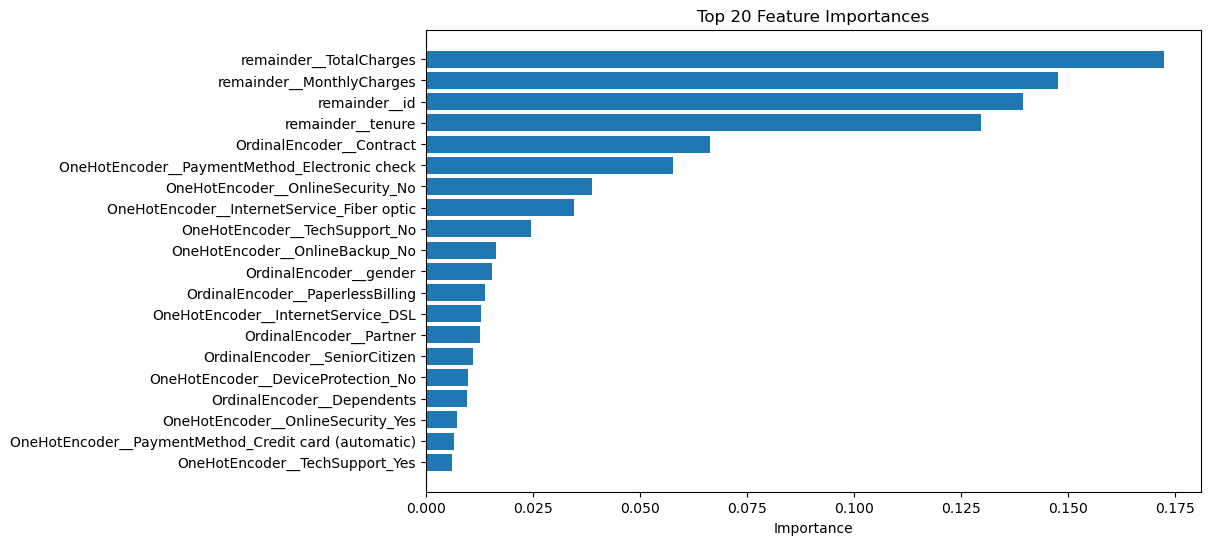

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

model = pipe.named_steps['model']

importances = model.feature_importances_

feature_names = pipe.named_steps['transform'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

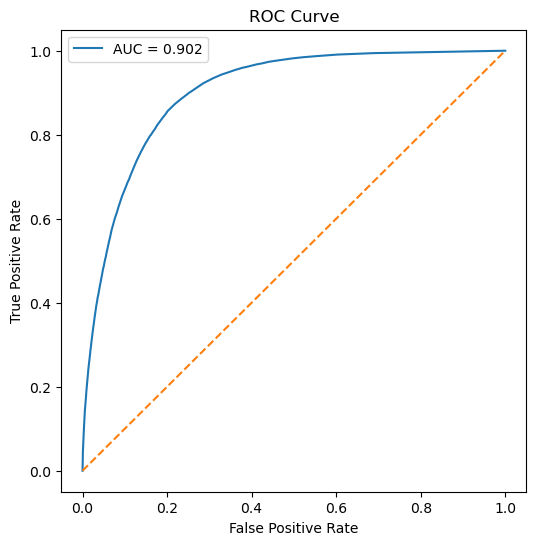

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = pipe.predict_proba(x_tst)[:,1]

fpr, tpr, thresholds = roc_curve(y_tst, y_prob, pos_label='Yes')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()